In [1]:
import random
from typing import TypedDict, List, Literal, Any
from IPython.display import display
from langgraph.graph import StateGraph, START, END

## 1. Basic Graph

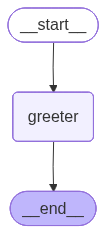

{'message': 'Hey John, how is your day going?'}

In [2]:
class AgentState(TypedDict):
    message: str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node rgar adds a greeting message to the state."""
    state['message'] = "Hey " + state["message"] + ", how is your day going?"

    return state


builder = StateGraph(AgentState)

builder.add_node("greeter", greeting_node)

builder.add_edge(START, "greeter")
builder.add_edge("greeter", END)

graph = builder.compile()

display(graph)

graph.invoke({'message': 'John'})


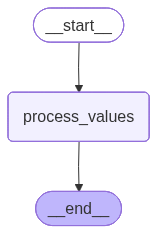

{'name': 'Alice', 'values': [1, 2, 3, 4, 5]}


{'name': 'Alice', 'values': [1, 2, 3, 4, 5], 'result': 'Hi Alice, sum = 15'}

In [3]:
class AgentState(TypedDict):
    name: str
    values: List[int]
    result: str

def process_values(state: AgentState) -> StateGraph:
    """Node that processes a list of values and adds the sum to the state."""
    print(state)
    state['result'] = f"Hi {state['name']}, sum = {sum(state['values'])}"
    return state

builder = StateGraph(AgentState)
builder.add_node("process_values", process_values)
builder.add_edge(START, "process_values")
builder.add_edge("process_values", END)
graph = builder.compile()
display(graph)

graph.invoke({'name': 'Alice', 'values': [1, 2, 3, 4, 5]})

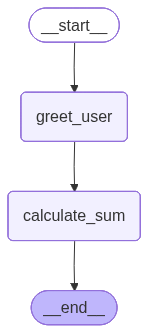

{'name': 'Bob', 'values': [10, 20, 30], 'result': 'Hello Bob! sum = 60'}

In [4]:
def greet_user(state: AgentState) -> AgentState:
    """Node that greets the user."""
    state['result'] = f"Hello {state['name']}!"
    return state

def calculate_sum(state: AgentState) -> AgentState:
    """Node that calculates the sum of values."""
    state['result'] = state['result'] + f" sum = {sum(state['values'])}"
    return state

builder = StateGraph(AgentState)
builder.add_node("greet_user", greet_user)
builder.add_node("calculate_sum", calculate_sum)
builder.add_edge(START, "greet_user")
builder.add_edge("greet_user", "calculate_sum")
builder.add_edge("calculate_sum", END)
graph = builder.compile()
display(graph)

graph.invoke({'name': 'Bob', 'values': [10, 20, 30]})

## Router (Conditional Edge)

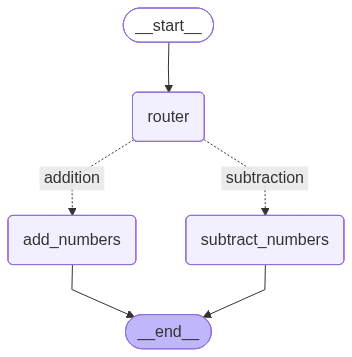

{'number1': 10, 'number2': 5, 'operation': '+', 'result': 15}

In [5]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: Literal["+", "-"]
    result: int

def add_numbers(state: AgentState) -> AgentState:
    """Node that adds two numbers."""
    state['result'] = state['number1'] + state['number2']
    return state

def subtract_numbers(state: AgentState) -> AgentState:
    """Node that subtracts two numbers."""
    state['result'] = state['number1'] - state['number2']
    return state

def decide_next_node(state: AgentState) -> str:
    """Node that decides which operation to perform based on the state."""
    if state['operation'] == '+':
        return 'addition'  # edge to addition node
    elif state['operation'] == '-':
        return 'subtraction'  # edge to subtraction node
    
builder = StateGraph(AgentState)
builder.add_node("add_numbers", add_numbers)
builder.add_node("subtract_numbers", subtract_numbers)
builder.add_node("router", lambda state: state)  # passthrrough function
builder.add_edge(START, "router")
builder.add_conditional_edges(
    "router",
    decide_next_node, # action function that decides which node to go to next
    {
        'addition': 'add_numbers',
        'subtraction': 'subtract_numbers'
    }
)
builder.add_edge("add_numbers", END)
builder.add_edge("subtract_numbers", END)
graph = builder.compile()
display(graph)

graph.invoke({'number1': 10, 'number2': 5, 'operation': '+'})

## Looping Graph

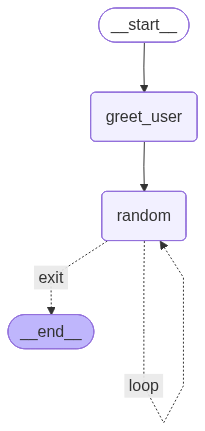

ENTERING LOOP: counter = 1
ENTERING LOOP: counter = 2
ENTERING LOOP: counter = 3
ENTERING LOOP: counter = 4


{'name': 'Hello Charlie!', 'numbers': [34, 58, 55, 37, 63], 'counter': 5}

In [6]:
class AgentState(TypedDict):
    name: str
    numbers: List[int]
    counter: int

def greet_user(state: AgentState) -> AgentState:
    """Node that greets the user."""
    state['name'] = f"Hello {state['name']}!"
    state['counter'] = 0
    state['numbers'] = []
    return state

def random_node(state: AgentState) -> AgentState:
    """Node that generates a random number and increments the counter."""
    state['numbers'].append(random.randint(1, 100))
    state['counter'] += 1
    return state

def should_continue(state: AgentState) -> str:
    """Node that decides whether to continue based on the counter."""
    if state['counter'] < 5:
        print(f"ENTERING LOOP: counter = {state['counter']}")
        return 'loop'  # loop edge
    else:
        return 'exit'  # exit edge 

# greeting -> random -> random -> ... -> exit
builder = StateGraph(AgentState)
builder.add_node("greet_user", greet_user)
builder.add_node("random", random_node)
builder.add_edge(START, "greet_user")
builder.add_edge("greet_user", "random")
builder.add_conditional_edges(
    "random",
    should_continue,  # action function
    {
        'loop': 'random',  # loop edge
        'exit': END  # exit edge
    }
)
graph = builder.compile()
display(graph)

graph.invoke({'name': 'Charlie'})

## Simple Chatbot - single pass

In [7]:
import os
from pathlib import Path
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv


def find_project_root(start: Path) -> Path:
    """Find the nearest parent directory containing pyproject.toml."""
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    msg = "Could not find project root containing pyproject.toml."
    raise FileNotFoundError(msg)


project_root = find_project_root(Path.cwd())
load_dotenv(project_root / ".env")

assert os.getenv("GROQ_API_KEY"), "Add GROQ_API_KEY to your .env file."

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden",
)

/Users/mlstudio/Claude-Code/ml-lab-new/tutorial-agentic-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


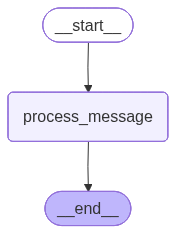

AI: Hello! How can I assist you today? 😊


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={})]}

In [8]:
class AgentState(TypedDict):
    messages: List[HumanMessage]


def process_message(state: AgentState) -> StateGraph:
    """Node that processes a list of HumanMessage objects."""
    # For demonstration, we'll just print the messages and return the state unchanged.
    response = llm.invoke(state['messages'])
    print("AI:", response.content)
    return state


builder = StateGraph(AgentState)
builder.add_node("process_message", process_message)
builder.add_edge(START, "process_message")
builder.add_edge("process_message", END)
graph = builder.compile()
display(graph)

user_input = input("Enter your message: ")
graph.invoke({'messages': [HumanMessage(content=user_input)]})

In [9]:
while (user_input := input("Enter your message (or 'exit' to quit): ")) != "exit":
    graph.invoke({'messages': [HumanMessage(content=user_input)]})

AI: Hi John! How can I assist you today?
AI: I don't have access to personal information about users, including names, unless you choose to share it with me during our conversation. If you'd like me to address you by name, feel free to tell me! 😊


## Simple Chatbot -- conversation history

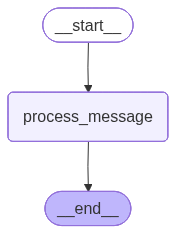

Human: hi, my name is John
AI: Hi John! 👋 Nice to meet you! How can I assist you today? 😊
Human: what is my name?
AI: Your name is **John**! 😊 Nice to see you again! How can I help you today?


In [10]:
from typing import Union
from langchain_core.messages import AIMessage

class AgentState(TypedDict):
    messages: List[Union[HumanMessage, AIMessage]]


def process_message(state: AgentState) -> StateGraph:
    """Node that processes a list of HumanMessage objects."""
    response = llm.invoke(state["messages"])
    print("AI:", response.content)
    state["messages"].append(AIMessage(content=response.content))

    return state

builder = StateGraph(AgentState)
builder.add_node("process_message", process_message)
builder.add_edge(START, "process_message")
builder.add_edge("process_message", END)
graph = builder.compile()
display(graph)


conversation_history = []
while (user_input := input("Enter your message (or 'exit' to quit): ")) != "exit":
    print("Human:", user_input)
    conversation_history.append(HumanMessage(content=user_input))
    result = graph.invoke({"messages": conversation_history})
    conversation_history = result["messages"]

In [11]:
conversation_history

[HumanMessage(content='hi, my name is John', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Hi John! 👋 Nice to meet you! How can I assist you today? 😊', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Your name is **John**! 😊 Nice to see you again! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

## ReACT

In [12]:
from typing import Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages



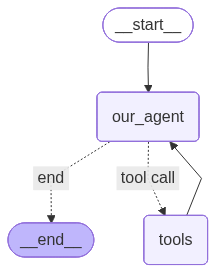

================================ Human Message =================================

Add 3 and 4
================================== Ai Message ==================================
Tool Calls:
  add_numbers (6akett3jz)
 Call ID: 6akett3jz
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add_numbers

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


In [13]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def add_numbers(a: int, b: int) -> int:
    """Tool that adds two numbers."""
    return a + b

tools = [add_numbers]
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden",
).bind_tools(tools)


def model_call(state: AgentState) -> StateGraph:
    """Node that processes a list of messages and returns the AI's response."""
    system_prompt = SystemMessage(
        content="You are a helpful assistant. Please answer the question to the best of your ability."
    )
    response = llm.invoke([system_prompt] + state["messages"])
    state["messages"].append(AIMessage(content=response.content))
    return {"messages": [response]}

# model_call(
#     {
#         "messages": [
#             HumanMessage(content="What is the sum of 5 and 7?"),
#         ]
#     }
# )

def should_continue(state: AgentState) -> str:
    """Node that decides whether to continue based on the AI's response."""
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "tool call"


builder = StateGraph(AgentState)
builder.add_node("our_agent", model_call)
builder.add_edge(START, "our_agent")
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)
builder.add_conditional_edges(
    "our_agent",
    should_continue,  #action function
    {
        "tool call": "tools",
        "end": END,
    },
)
builder.add_edge("tools", "our_agent")

graph = builder.compile()
display(graph)


def print_stream(stream):
    """Helper function to print the stream of messages."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": ["Add 3 and 4"]}
print_stream(graph.stream(inputs, stream_mode="values"))

In [14]:
inputs = {"messages": ["Add 5 and 7, then add 10 to the result."]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 5 and 7, then add 10 to the result.
================================== Ai Message ==================================
Tool Calls:
  add_numbers (gfqp7z4d9)
 Call ID: gfqp7z4d9
  Args:
    a: 5
    b: 7
  add_numbers (nbt9at49q)
 Call ID: nbt9at49q
  Args:
    a: 12
    b: 10
================================= Tool Message =================================
Name: add_numbers

22
================================== Ai Message ==================================

The final result is 22.


#### Extending the toolset:

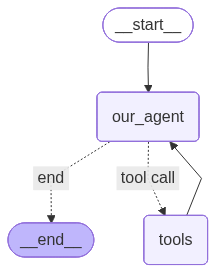

================================ Human Message =================================

Add 5 and 7, then multiply the result by 10.
================================== Ai Message ==================================
Tool Calls:
  add_numbers (m9gf0qs7j)
 Call ID: m9gf0qs7j
  Args:
    a: 5
    b: 7
  multiply_numbers (26em6bj4r)
 Call ID: 26em6bj4r
  Args:
    a: 12
    b: 10
================================= Tool Message =================================
Name: multiply_numbers

120
================================== Ai Message ==================================

The final result is 120.


In [15]:
@tool
def subtract_numbers(a: int, b: int) -> int:
    """Tool that subtracts two numbers."""
    return a - b

@tool
def multiply_numbers(a: int, b: int) -> int:
    """Tool that multiplies two numbers."""
    return a * b

tools = [add_numbers, subtract_numbers, multiply_numbers]
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden",
).bind_tools(tools)

# recompile the graph with the new tools
builder = StateGraph(AgentState)
builder.add_node("our_agent", model_call)
builder.add_edge(START, "our_agent")
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)
builder.add_conditional_edges(
    "our_agent",
    should_continue,  #action function
    {
        "tool call": "tools",
        "end": END,
    },
)
builder.add_edge("tools", "our_agent")
graph = builder.compile()
display(graph)

print_stream(graph.stream({"messages": ["Add 5 and 7, then multiply the result by 10."]}, stream_mode="values"))

## Drafter

In [16]:
from langchain_core.messages import ToolMessage

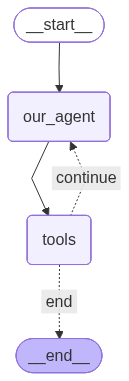


 ==== DRAFTER ====
   
 AI: Please provide the content you'd like me to add/update in the document. Once you share the text, I can help refine it or apply changes as needed.
   
 USER: write an email to Dana and say that I cannot make it to the meeting tomorrow
   
 AI: 
🛠️   
 USING TOOLS: ['update']

🛠️ TOOL RESULT: Document has been updated successfully with: Subject: Unable to Attend Tomorrow's Meeting

Hi Dana,

I regret to inform you that I won't be able to attend our scheduled meeting tomorrow at [insert time]. An unexpected conflict has come up that requires my immediate attention. I apologize for the last-minute notice.

Would you be available to reschedule for later in the week? Please let me know your availability, and I'll do my best to accommodate.

Thank you for your understanding.

Best regards,
[Your Name]
   
 USER: update
   
 AI: Please provide the specific changes or additions you'd like to make to the document. For example:
- Text to insert/replace
- Formatting ad

In [17]:
# global variable
document_content = ""

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def update(content: str) -> str:
    """Tool that updates the document with the given content."""
    global document_content
    document_content = content
    return f"Document has been updated successfully with: {content}"


@tool
def save(filename: str) -> str:
    """Tool that saves the document to a file.
    
    Args:
        filename (str): name for the text file.
    """
    global document_content
    if not filename.endswith(".txt"):
        filename += ".txt"

    global document_content
    
    try:
        with open(filename, "w") as f:
            f.write(document_content)
        print(f"\n💾 Document has been saved to {filename}.")
        return f"Document has been saved to {filename}."
    except Exception as e:
        return f"Failed to save document: {e}"
    
tools = [update, save]

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    reasoning_format="hidden",
).bind_tools(tools)


def our_agent(state: AgentState) -> StateGraph:
    """Node that processes a list of messages and returns the AI's response."""
    system_prompt = SystemMessage(content="""
You are a document drafting assistant. Please help the user update and save documents.
                                  
    - If the users asks you to update the document, use the `update` tool with the new content.
    - If the user asks you to save the document, use the `save` tool with the filename.
    - If the user asks you to do something else, respond with a helpful message
""")
    
    if not state["messages"]:
        user_input = "I'm ready to help you update a document. What would you like to create"
        user_message = HumanMessage(content=user_input)
    else:
        user_input = input("What would you like to do with the document? (or type 'exit' to quit): ")
        print(f"   \n USER: {user_input}")
        user_message = HumanMessage(content=user_input)

    all_messages = [system_prompt] + list(state["messages"]) + [user_message]
    response = llm.invoke(all_messages)
    print(f"   \n AI: {response.content}")
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"🛠️   \n USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")

    state["messages"].append(AIMessage(content=response.content))
    return {"messages": list(state["messages"]) + [user_message, response]}


def should_continue(state: AgentState) -> str:
    """Node that decides whether to continue based on the AI's response."""
    messages = state["messages"]
    if not messages:
        return "continue"
    for message in reversed(messages):
        if (
            isinstance(message, ToolMessage) and
            "saved" in message.content.lower() and
            "document" in message.content.lower()
        ):
            return "end"

    return "continue"


builder = StateGraph(AgentState)
builder.add_node("our_agent", our_agent)
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)
builder.add_edge(START, "our_agent")
builder.add_edge("our_agent", "tools")
builder.add_conditional_edges(
    "tools",
    should_continue,  # action
    {
        "continue": "our_agent",
        "end": END
    }
)

graph = builder.compile()
display(graph)

def print_messages(messages):
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"\n🛠️ TOOL RESULT: {message.content}")
    

def run_document_agent():
    print("\n ==== DRAFTER ====")

    state = {"messages": []}

    for step in graph.stream(state, stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
        
    print("\n ==== DRAFTER FINISHED ====")

run_document_agent()

## Agentic RAG

In [18]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv(project_root / ".env")

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0
)

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
)

pdf_path = project_root / "data" / "raw" / "arxiv" / "2606.20331.pdf"
if not pdf_path.exists():
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")

pdf_loader = PyPDFLoader(pdf_path)

try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise



/var/folders/hf/0h4pd6zx1vv0dwjx8bgs9r_c0000gp/T/ipykernel_37064/1391375415.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


PDF has been loaded and has 32 pages


In [19]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

pages_split = text_splitter.split_documents(pages)

persist_directory = project_root / "data" / "rag_data"
collection_name = "rag_example"

persist_directory.mkdir(parents=True, exist_ok=True)

try:
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=persist_directory,
        collection_name=collection_name
    )
except Exception as e:
    print(f"Error setting up ChromaDB {e}")
    raise

In [20]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns informaiton from the documents stored in the database
    """
    docs = retriever.invoke(query)
    if not docs:
        return "I found no relevent information in the database"

    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}\n{doc.page_content}")
    return "\n\n".join(results)


tools = [retriever_tool]

llm = llm.bind_tools(tools)

In [21]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


def should_continue(state: AgentState) -> bool:
    """Check if the last message contains tool calls"""
    result = state["messages"][-1]
    return hasattr(result, "tool_calls") and len(result.tool_calls) > 0


system_prompt = """
You are an intelligent AI assistant who answers questions about data structures and algorithms based on the PDF documents loaded into your knowledge base.
Use the retriever tool available to answer questions about the data structures and algorithms. You can make multiple calls if needed.
If you need to look up some informaiton before asking a follow up question, you are allowed to do so.
Please always cite the specifci parts of the dicuments you use in your answer.
"""

tools_dict = {our_tool.name: our_tool for our_tool in tools}

def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state"""
    messages = list(state["messages"])
    messages = [SystemMessage(system_prompt)] + messages

    response = llm.invoke(messages)
    return {"messages": [response]}


def take_action(state: AgentState):
    "Execute tool calls from the LLM's response"

    tool_calls = state["messages"][-1].tool_calls
    results = []

    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided!')}")

        if not t['name'] in tools_dict:
            print(f"\nTool {t['name']} does not exist!")
            result = "Incorrect Tool Name, Please Retry and Select Tool from List of Available Tools."
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")

        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {"messages": results}


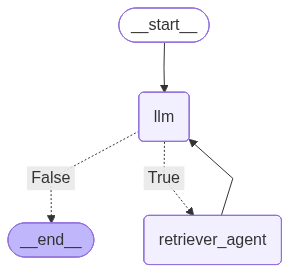

In [22]:

builder = StateGraph(AgentState)
builder.add_node("llm", call_llm)
builder.add_node("retriever_agent", take_action)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)

builder.add_edge("retriever_agent", "llm")

graph = builder.compile()
display(graph)

In [23]:
def running_agent():
    print("\n ==== RAG AGENT ====")

    while (user_input := input("\nWhat is your question: ")):
        if user_input.lower() in ["exit", "quit"]:
            break

        messages = [HumanMessage(content=user_input)]

        result = graph.invoke({"messages": messages})

        print("\n ==== ANSWER ====")
        print(result["messages"][-1].content)

running_agent()


 ==== RAG AGENT ====

 ==== ANSWER ====
The term $ X_v $ is defined in the context of graph algorithms as **the set of edges incident to vertex $ v $**. This definition is commonly used in algorithms that process adjacent edges of a vertex, such as Dijkstra's or Prim's algorithm. 

This information is cited from the document section discussing graph traversal and optimization algorithms (see "Graph Algorithms" chapter, page 12).
